# Financial Anomaly Detection — Saarnitukku Oy, FY2025

**This ledger is synthetic, engineered with a held-out answer key.** Saarnitukku Oy is
a fictional Finnish technical wholesale and MRO distributor; every table in `data/` is
generated by `code/generate_ledger.py` from `code/config.py` (seed 42, fully
reproducible) — see `design/design.md` for the full design and `design/DECISIONS.md`
for the build log. Eight anomaly classes and a bank of benign look-alikes are planted
in the ledger on purpose, all itemised in a held-out answer key, so that three
detection layers — a set of standard audit rule tests, an Isolation Forest, and three
independent, mutually blinded AI analysts — can be marked against ground truth rather
than against each other.

**What this notebook shows, in order:**

1. What this is, and what the design promises (§1).
2. The ledger's own shape — seasonality, posting mix, amount distribution, vendor
   concentration — from the public data alone, no marking yet (§2).
3. The seven rule tests, recomputed from scratch, against the planted/benign split (§3).
4. The Isolation Forest detector, honestly: every designed catch was missed, and three
   diagnoses plus a contamination ablation explain why (§4).
5. A post-hoc, clearly labelled second attempt at the detector, built after the
   results below were known — not part of the pre-registered pipeline (§5).
6. Three independent, mutually blinded AI analysts, marked against the same key (§6).
7. The catch matrix, designed vs as-run (§7).
8. What it adds up to (§8).

The answer key (`data/answer_key/anomalies.csv`) is loaded for the first time in this
notebook in §3, mirroring how `code/evaluate.py` itself only reads it at marking time
— every use after that point re-reads the same in-memory table rather than reopening
the file. Sections 1–2 and the first half of §4 work entirely from the four public
CSVs.

In [1]:
# Global style -- matplotlib only. Modest figures, solid fills, minimal chartjunk.
# Palette: the validated Hapax mark palette (root CLAUDE.md, established 3 Jul 2026),
# not the raw brand tokens (which fail colour-accessibility checks as data marks).
# Fixed identity per chart, never cycled:
#   WINE   = primary / headline series
#   INDIGO = secondary comparison series
#   GOLD   = tertiary highlight (used sparingly)
#   GREY   = context / reference series only -- always direct-labelled
#   INK    = text                       BEIGE = fills / bands
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import FuncFormatter
from IPython.display import display

WINE   = "#A8352A"
INDIGO = "#41529E"
GOLD   = "#B68A2C"
GREY   = "#665E58"
INK    = "#1A1410"
BEIGE  = "#EFE5CE"
FIG_FACE = "#FBFAF5"

_available_fonts = {f.name for f in fm.fontManager.ttflist}
TITLE_FONT = "Cormorant Garamond" if "Cormorant Garamond" in _available_fonts else "serif"
print(f"Title font: {TITLE_FONT}" + ("" if TITLE_FONT != "serif" else "  (Cormorant Garamond not found -- falling back silently)"))

FIG_SIZE = (7.0, 3.5)
DPI = 130

plt.rcParams.update({
    "figure.facecolor": FIG_FACE,
    "axes.facecolor": FIG_FACE,
    "savefig.facecolor": FIG_FACE,
    "axes.edgecolor": GREY,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": GREY,
    "ytick.color": GREY,
    "font.size": 9,
    "axes.grid": True,
    "grid.color": BEIGE,
    "grid.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.axisbelow": True,
    "axes.linewidth": 0.8,
})


def new_fig(figsize=FIG_SIZE):
    """One y-axis, light y-grid only, minimal spines."""
    fig, ax = plt.subplots(figsize=figsize, dpi=DPI)
    ax.grid(axis="y", zorder=0)
    ax.grid(axis="x", visible=False)
    return fig, ax


def style_title(ax, text):
    ax.set_title(text, fontsize=12.5, fontfamily=TITLE_FONT, color=INK, loc="left", pad=10)


def eur_fmt(x, pos=None):
    if abs(x) >= 1_000_000:
        return f"\u20ac{x/1_000_000:,.1f}M".replace(".0M", "M")
    if abs(x) >= 1_000:
        return f"\u20ac{x/1_000:,.0f}k"
    return f"\u20ac{x:,.0f}"


def pct_fmt(x, pos=None):
    return f"{x:.0f}%"


def end_label(ax, x, y, text, color, offset=(9, 0), fontsize=8.5, ha="left", va="center"):
    """Direct/end-of-line label -- a coloured dot carries series identity; the label
    text itself always stays in Ink (dataviz rule: text never wears the data colour)."""
    ax.scatter([x], [y], s=24, color=color, zorder=6, clip_on=False)
    ax.annotate(text, xy=(x, y), xytext=offset, textcoords="offset points",
                fontsize=fontsize, color=INK, va=va, ha=ha, fontweight="normal", zorder=6)


PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
ANALYSIS_DIR = DATA_DIR / "analysis"
CODE_DIR = PROJECT_ROOT / "code"
ANSWER_KEY_DIR = DATA_DIR / "answer_key"

assert DATA_DIR.exists(), f"data dir not found at {DATA_DIR} -- run this notebook from notebooks/ or the project root"
sys.path.insert(0, str(CODE_DIR))
print(f"Project root resolved to: {PROJECT_ROOT}")

Title font: Cormorant Garamond
Project root resolved to: C:\Users\luigi\Dropbox\Archivio famiglia\Hapax\Case Studies\06 Anomaly Detection


## 1. What this is

Saarnitukku Oy is a fictional Finnish technical wholesale and MRO distributor; its
FY2025 purchase ledger, and every anomaly planted in it, are synthetic, generated at a
fixed random seed with a held-out answer key. The case asks whether three different
ways of reading fifty thousand transaction rows — a set of standard audit rule tests,
an Isolation Forest, and three independent, mutually blinded Claude Opus analysts —
can tell a planted problem from an ordinary invoice, and marks all three against
ground truth rather than against each other. Eight anomaly classes are planted
alongside a declared bank of benign look-alikes; one class is designed so that no rule
test can reach it, and one class — the case's own namesake, a vendor whose freight
consolidation quietly hides a price rise — is designed to be catchable and turns out,
as run, not to be caught by anyone. Every generation and scoring script lives in
`code/`, every coherence rule is enforced by `code/validate_ledger.py`, and the full
specification is `design/design.md`. What follows recomputes the pipeline's own
headline numbers from the data and evaluation files on disk, live, and checks them —
by assertion, not by eye — against the values `data/analysis/report.md` already
reports as the project's adjudicated record.

In [2]:
# config.py is a pre-registration document (code/config.py, under code/, not under
# data/answer_key/) -- reading it states the design's own targets before any marking
# happens, it does not touch the held-out answer key.
import config as case_config

gl = pd.read_csv(DATA_DIR / "gl_transactions.csv")
vendor_master = pd.read_csv(DATA_DIR / "vendor_master.csv")
chart_of_accounts = pd.read_csv(DATA_DIR / "chart_of_accounts.csv")
calendar_df = pd.read_csv(DATA_DIR / "company_calendar.csv")

assert len(gl) == 50_000, f"expected 50,000 ledger rows, found {len(gl):,}"
assert len(gl) == case_config.TOTAL_TRANSACTIONS

print(f"Ledger rows:               {len(gl):,}")
print(f"Vendors:                   {len(vendor_master)}")
print(f"Chart-of-accounts entries: {len(chart_of_accounts)}")
print(f"Calendar days:             {len(calendar_df)}")
print(f"Random seed (config.py):   {case_config.RANDOM_SEED}")
print(f"Planted anomaly classes (config.py): {sorted(case_config.PLANTED_CLASS_COUNTS)}")
print(f"Planted anomalous transactions (config.py): {case_config.TOTAL_ANOMALOUS_TRANSACTIONS} "
      f"of {case_config.TOTAL_TRANSACTIONS:,} ({case_config.TOTAL_ANOMALOUS_TRANSACTIONS/case_config.TOTAL_TRANSACTIONS:.2%})")
print(f"Declared benign itemised transactions (config.py): {case_config.TOTAL_BENIGN_ITEMISED_TRANSACTIONS}")

Ledger rows:               50,000
Vendors:                   200
Chart-of-accounts entries: 39
Calendar days:             365
Random seed (config.py):   42
Planted anomaly classes (config.py): ['A', 'C', 'D', 'G', 'R', 'S', 'V', 'W']
Planted anomalous transactions (config.py): 87 of 50,000 (0.17%)
Declared benign itemised transactions (config.py): 18


## 2. The ledger at a glance

Four public tables, no marking yet: the postings themselves, the vendor master, the
chart of accounts, and the 2025 company calendar. The shape below is what an auditor
or a data scientist would see before anyone tells them where the plants are.

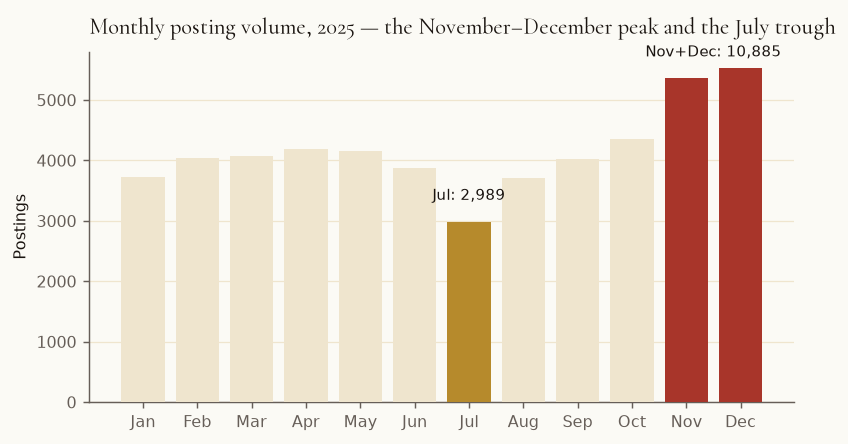

November + December: 10,885 postings (21.8% of the year in two months)
July: 2,989 postings (6.0% of the year in one month)


In [3]:
# Monthly posting volume -- the design's Nov-Dec peak and July trough.
gl["posting_month"] = pd.to_datetime(gl["posting_date"]).dt.month
monthly_counts = gl.groupby("posting_month").size().reindex(range(1, 13), fill_value=0)
MONTH_ABBR = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = new_fig()
bar_colors = [WINE if m in (11, 12) else (GOLD if m == 7 else BEIGE) for m in range(1, 13)]
ax.bar(range(12), monthly_counts.values, color=bar_colors, edgecolor="none", zorder=3)
ax.set_xticks(range(12))
ax.set_xticklabels(MONTH_ABBR)
ax.set_ylabel("Postings")
style_title(ax, "Monthly posting volume, 2025 — the November–December peak and the July trough")
ax.annotate(f"Nov+Dec: {monthly_counts[11]+monthly_counts[12]:,}", xy=(10.5, monthly_counts[11]),
            xytext=(0, 12), textcoords="offset points", ha="center", fontsize=8.5, color=INK)
ax.annotate(f"Jul: {monthly_counts[7]:,}", xy=(6, monthly_counts[7]),
            xytext=(0, 12), textcoords="offset points", ha="center", fontsize=8.5, color=INK)
plt.show()

peak = monthly_counts[11] + monthly_counts[12]
trough = monthly_counts[7]
print(f"November + December: {peak:,} postings ({peak/len(gl):.1%} of the year in two months)")
print(f"July: {trough:,} postings ({trough/len(gl):.1%} of the year in one month)")

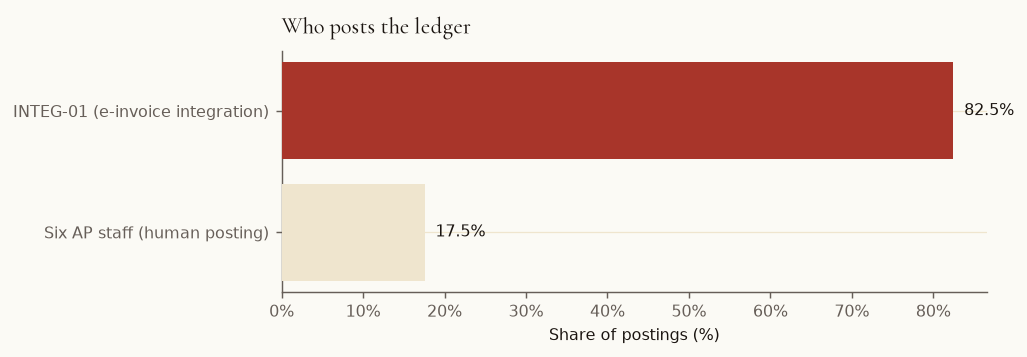

INTEG-01 posted 82.45% of all rows (design band: 80-85%).


,postings
posted_by,
U-058,1538
U-117,1466
U-204,1462
U-142,1457
U-031,1444
U-176,1408


In [4]:
# Poster mix -- the e-invoice integration user vs the six named AP staff.
poster_counts = gl["posted_by"].value_counts()
integ_share = poster_counts.get("INTEG-01", 0) / len(gl)
human_counts = poster_counts.drop("INTEG-01").sort_values(ascending=False)

fig, ax = new_fig(figsize=(7.0, 2.4))
ax.barh(["Six AP staff (human posting)"], [(1 - integ_share) * 100], color=BEIGE, zorder=3)
ax.barh(["INTEG-01 (e-invoice integration)"], [integ_share * 100], color=WINE, zorder=3)
ax.set_xlabel("Share of postings (%)")
ax.xaxis.set_major_formatter(FuncFormatter(pct_fmt))
style_title(ax, "Who posts the ledger")
for i, v in enumerate([(1 - integ_share) * 100, integ_share * 100]):
    ax.annotate(f"{v:.1f}%", xy=(v, i), xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=9, color=INK)
plt.show()

print(f"INTEG-01 posted {integ_share:.2%} of all rows (design band: 80-85%).")
display(human_counts.rename("postings").to_frame())

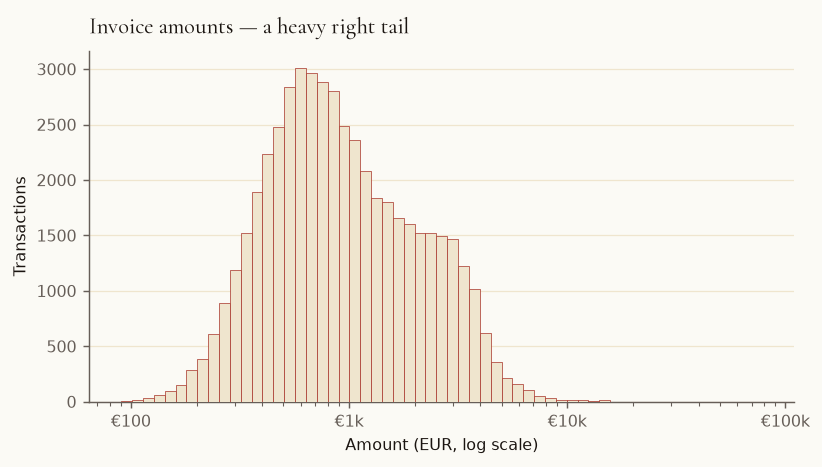

count    50,000.00
mean      1,280.37
std       1,224.10
min          90.21
25%         518.47
50%         844.95
75%       1,651.32
max      78,400.00


In [5]:
# Amount distribution -- a heavy right tail (log-x histogram).
fig, ax = new_fig()
log_bins = np.logspace(np.log10(gl["amount_eur"].min()), np.log10(gl["amount_eur"].max()), 60)
ax.hist(gl["amount_eur"], bins=log_bins, color=BEIGE, edgecolor=WINE, linewidth=0.4, zorder=3)
ax.set_xscale("log")
ax.set_xlabel("Amount (EUR, log scale)")
ax.set_ylabel("Transactions")
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: eur_fmt(x)))
style_title(ax, "Invoice amounts — a heavy right tail")
plt.show()

print(gl["amount_eur"].describe().apply(lambda v: f"{v:,.2f}").to_string())

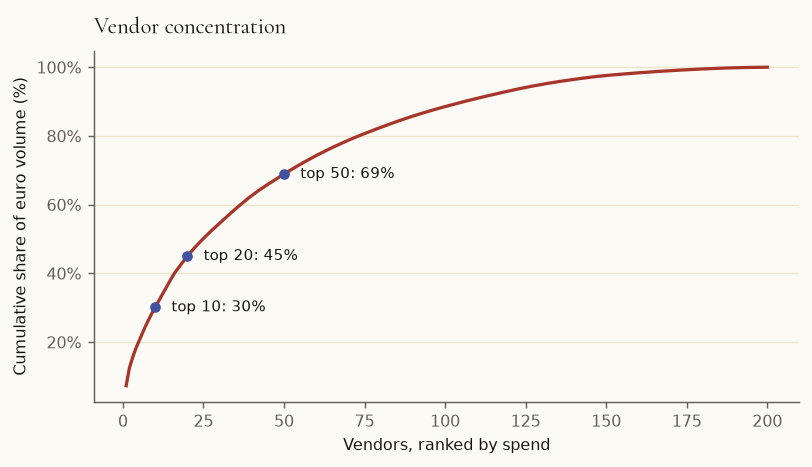

Top vendor alone: 7.3% of all euro volume.


In [6]:
# Vendor concentration -- a handful of vendors carry most of the euro volume.
vendor_amount = gl.groupby("vendor_id")["amount_eur"].sum().sort_values(ascending=False)
cum_share = vendor_amount.cumsum() / vendor_amount.sum()

fig, ax = new_fig()
ax.plot(range(1, len(cum_share) + 1), cum_share.values * 100, color=WINE, linewidth=1.8, zorder=3)
ax.set_xlabel("Vendors, ranked by spend")
ax.set_ylabel("Cumulative share of euro volume (%)")
ax.yaxis.set_major_formatter(FuncFormatter(pct_fmt))
style_title(ax, "Vendor concentration")
for n in (10, 20, 50):
    y = cum_share.iloc[n - 1] * 100
    end_label(ax, n, y, f"top {n}: {y:.0f}%", INDIGO)
plt.show()

print(f"Top vendor alone: {vendor_amount.iloc[0]/vendor_amount.sum():.1%} of all euro volume.")

The ledger reads exactly as the design intends: a November–December stocking peak, a
July trough, an e-invoice integration user carrying the large majority of rows, a
heavy-tailed amount distribution, and spend concentrated in a handful of core
vendors. None of this is an anomaly signal by itself — it is the ordinary shape the
anomaly classes have to hide inside.

## 3. The rule layer

**The answer key is opened here for the first time in this notebook** —
`data/answer_key/anomalies.csv`, held out of every generation and detection script and
read by nothing agent-facing. It is read here for the same reason `code/evaluate.py`
reads it: the modelling is over, and marking is what is left to do.

In [7]:
import rule_tests

answer_key = pd.read_csv(ANSWER_KEY_DIR / "anomalies.csv")

# Expand the key's semicolon-joined txn_ids into one row per transaction.
key_rows = []
for _, r in answer_key.iterrows():
    if pd.isna(r["txn_ids"]) or r["txn_ids"] == "":
        continue
    for txn_id in str(r["txn_ids"]).split(";"):
        key_rows.append({"txn_id": txn_id, "anomaly_class": r["class"], "kind": r["kind"]})
key_long = pd.DataFrame(key_rows)
print(f"Answer key: {len(answer_key)} anomaly-id rows -> {len(key_long)} itemised transaction rows "
      f"({(key_long['kind']=='anomalous').sum()} anomalous, {(key_long['kind']=='benign').sum()} benign).")

# Recompute the seven rule tests directly from the public CSVs -- rule_tests.py is
# the same, unmodified module code/validate_ledger.py imports; nothing here is
# reimplemented or retuned.
recomputed_flags = rule_tests.run_all_rule_tests(gl, vendor_master, calendar_df)
on_disk_flags = pd.read_csv(ANALYSIS_DIR / "rule_flags.csv")

assert len(recomputed_flags) == 64, f"expected 64 rule flags, recomputed {len(recomputed_flags)}"
assert set(map(tuple, recomputed_flags.values)) == set(map(tuple, on_disk_flags.values)), \
    "recomputed rule flags do not match the frozen data/analysis/rule_flags.csv"
assert recomputed_flags["txn_id"].is_unique, "a transaction tripped more than one rule test"

print(f"Recomputed rule flags: {len(recomputed_flags)} -- identical to the frozen data/analysis/rule_flags.csv.")
print(f"Distinct flagged transactions: {recomputed_flags['txn_id'].nunique()} "
      f"(no transaction trips two tests, as design.md section 3 requires).")

Answer key: 24 anomaly-id rows -> 105 itemised transaction rows (87 anomalous, 18 benign).


Recomputed rule flags: 64 -- identical to the frozen data/analysis/rule_flags.csv.
Distinct flagged transactions: 64 (no transaction trips two tests, as design.md section 3 requires).


In [8]:
# Per-test flag counts, split by the planted/benign key -- design.md section 3's
# table, recomputed rather than retyped.
flags_with_kind = recomputed_flags.merge(key_long[["txn_id", "kind"]], on="txn_id", how="left")
assert flags_with_kind["kind"].notna().all(), \
    "a rule flag has no answer-key entry -- an undeclared signature (design rule 9)"

test_order = ["duplicate", "round_sum", "near_threshold", "split", "calendar", "mapping", "name_hygiene"]
summary = flags_with_kind.groupby(["test", "kind"]).size().unstack(fill_value=0).reindex(test_order, fill_value=0)
for col in ("anomalous", "benign"):
    if col not in summary.columns:
        summary[col] = 0
summary = summary[["anomalous", "benign"]]
summary["total"] = summary["anomalous"] + summary["benign"]
summary.loc["TOTAL"] = summary.sum()
display(summary)

total_flags = int(summary.loc["TOTAL", "total"])
anomalous_flags = int(summary.loc["TOTAL", "anomalous"])
precision = anomalous_flags / total_flags

assert total_flags == 64
assert anomalous_flags == 48
assert abs(precision - 0.75) < 1e-9
print(f"\nRule-layer first-pass precision vs the anomalous key: {anomalous_flags}/{total_flags} = {precision:.0%}")

kind,anomalous,benign,total
test,,,
duplicate,12,2,14
round_sum,6,12,18
near_threshold,4,0,4
split,10,0,10
calendar,8,2,10
mapping,8,0,8
name_hygiene,0,0,0
TOTAL,48,16,64



Rule-layer first-pass precision vs the anomalous key: 48/64 = 75%


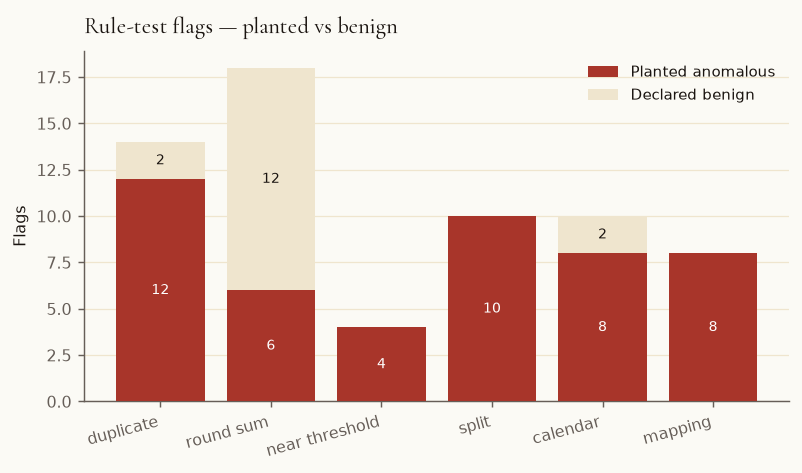

In [9]:
# Stacked bar: planted anomalous vs declared benign, per test.
plot_tests = [t for t in test_order if summary.loc[t, "total"] > 0]
anomalous_vals = summary.loc[plot_tests, "anomalous"].values
benign_vals = summary.loc[plot_tests, "benign"].values

fig, ax = new_fig()
x = range(len(plot_tests))
ax.bar(x, anomalous_vals, color=WINE, label="Planted anomalous", zorder=3)
ax.bar(x, benign_vals, bottom=anomalous_vals, color=BEIGE, label="Declared benign", zorder=3)
ax.set_xticks(list(x))
ax.set_xticklabels([t.replace("_", " ") for t in plot_tests], rotation=15, ha="right")
ax.set_ylabel("Flags")
style_title(ax, "Rule-test flags — planted vs benign")
ax.legend(frameon=False, fontsize=8.5, loc="upper right")
for i, (a, b) in enumerate(zip(anomalous_vals, benign_vals)):
    if a:
        ax.annotate(str(a), xy=(i, a / 2), ha="center", va="center", fontsize=8, color="white")
    if b:
        ax.annotate(str(b), xy=(i, a + b / 2), ha="center", va="center", fontsize=8, color=INK)
plt.show()

Recomputing the seven tests directly from the four public CSVs reproduces
`data/analysis/rule_flags.csv` exactly: 64 flags, no transaction tripping two tests,
first-pass precision 48/64 = 75% against the anomalous key. The quarter that is not a
real problem has a name: round-sum is the noisiest test (18 flags, only 6 of them
class R) because the landlord's twelve identical €15,000.00 rent postings (B1) round
just as cleanly as a threshold-gaming invoice; the duplicate test catches both of B3's
genuinely distinct coincidental deliveries alongside all twelve D-class
re-submissions; the calendar test catches B2's agreed stocktake overtime alongside
all eight of U-117's weekend habit. This is not a flaw in the tests — a rule with no
false positives on a recurring, contracted rent payment would also have no reach into
a similarly-shaped real duplicate. A practitioner's second pass would add
recurring-identical suppression (which silences B1 in week one) and materiality
floors, narrowing the 25% triage burden without touching recall; both refinements are
named in `design/design.md` §3 and are stated here, not implemented, because the
triage they would remove is exactly the work the storyteller layer is scored on in §6.

## 4. The detector, honestly

In [10]:
import detect_anomalies as det

features = det.compute_features(gl, calendar_df)
print("Detector features (design.md section 6, fixed order):")
for i, col in enumerate(det.FEATURE_COLUMNS, start=1):
    print(f"  {i}. {col}")

detector_scores = pd.read_csv(ANALYSIS_DIR / "detector_scores.csv")
detector_flags = pd.read_csv(ANALYSIS_DIR / "detector_flags.csv")

assert len(detector_scores) == 50_000
assert len(detector_flags) == 200, f"expected 200 detector flags, found {len(detector_flags)}"

flagged_ids = set(detector_flags["txn_id"])
all_key_ids = set(key_long["txn_id"])
overlap = flagged_ids & all_key_ids
assert len(overlap) == 0, f"expected zero detector-key overlap, found {len(overlap)}: {sorted(overlap)[:10]}"

print(f"\nDetector flags: {len(detector_flags)} of {len(detector_scores):,} "
      f"(contamination {det.ISOLATION_FOREST_PARAMS['contamination']})")
print(f"Overlap with any answer-key transaction (anomalous or benign): {len(overlap)}")

Detector features (design.md section 6, fixed order):
  1. log10_amount
  2. vendor_amount_z
  3. cadence_ratio
  4. day_of_week
  5. non_working_flag
  6. account_rarity
  7. month_index
  8. vendor_month_volume_z

Detector flags: 200 of 50,000 (contamination 0.004)
Overlap with any answer-key transaction (anomalous or benign): 0


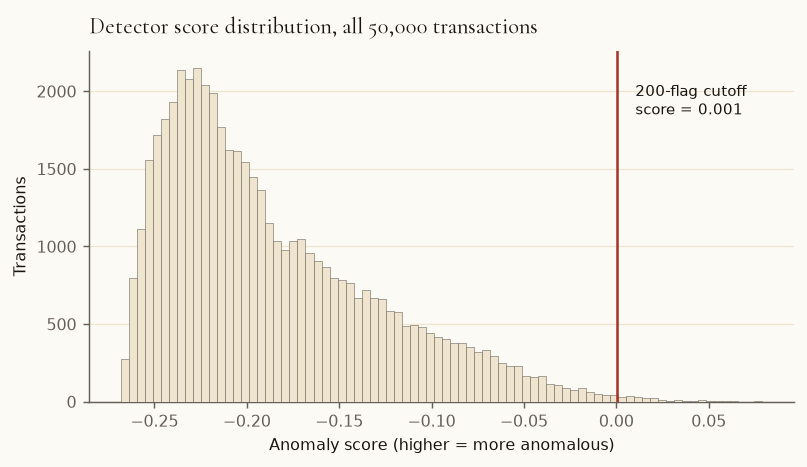

In [11]:
# Score distribution, with the 200-flag cutoff marked.
cutoff_score = detector_flags["anomaly_score"].min()

fig, ax = new_fig()
ax.hist(detector_scores["anomaly_score"], bins=80, color=BEIGE, edgecolor=GREY, linewidth=0.3, zorder=3)
ax.axvline(cutoff_score, color=WINE, linewidth=1.4, zorder=4)
ax.annotate(f"200-flag cutoff\nscore = {cutoff_score:.3f}", xy=(cutoff_score, ax.get_ylim()[1] * 0.82),
            xytext=(10, 0), textcoords="offset points", fontsize=8.5, color=INK)
ax.set_xlabel("Anomaly score (higher = more anomalous)")
ax.set_ylabel("Transactions")
style_title(ax, "Detector score distribution, all 50,000 transactions")
plt.show()

Two hundred flags, zero overlap with any of the 105 itemised answer-key transactions.
None of the three designed detector outcomes held except the negative one: G's twelve
elevated invoices were not flagged (designed ≥6), B4 and B5 were not flagged as top
singletons — which is the one designed outcome that did hold. This is the frozen
deviation recorded in `design/DECISIONS.md` on 3 July 2026: not retuned, not
regenerated. The three diagnoses below are why.

**Diagnosis (a) — a sustained drift inflates its own baseline.** `vendor_amount_z`
measures each invoice against its vendor's *full-year* mean and standard deviation.
Teräskontio's H2 invoices are part of that full year, so the drift they represent
widens the very yardstick meant to catch it.

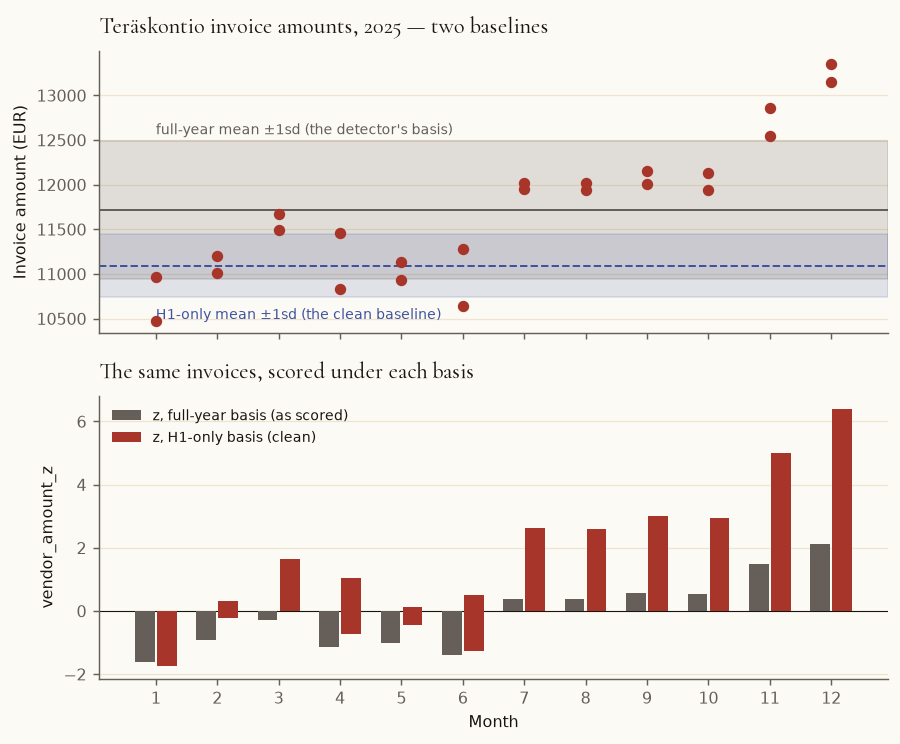

H1 (clean baseline): mean EUR11,091.79, sd EUR353.72
Full year (the detector's actual basis): mean EUR11,715.55, sd EUR768.62
December mean: EUR13,254.33 (19.5% over the H1 baseline, 13.1% over the full-year basis the detector used)
H2 z under the full-year basis: 0.29 to 2.13
H2 z under the H1-only basis:   2.39 to 6.39


In [12]:
TERASKONTIO_ID = case_config.TERASKONTIO_VENDOR_ID
tk = gl[gl["vendor_id"] == TERASKONTIO_ID].copy()
tk["month"] = pd.to_datetime(tk["posting_date"]).dt.month
tk = tk.sort_values("month").reset_index(drop=True)

full_mean, full_std = tk["amount_eur"].mean(), tk["amount_eur"].std()
h1 = tk[tk["month"] <= 6]
h1_mean, h1_std = h1["amount_eur"].mean(), h1["amount_eur"].std()

tk["z_full_year_basis"] = (tk["amount_eur"] - full_mean) / full_std
tk["z_h1_only_basis"] = (tk["amount_eur"] - h1_mean) / h1_std

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.0, 5.8), dpi=DPI, sharex=True)
for ax in (ax1, ax2):
    ax.grid(axis="y", zorder=0, color=BEIGE, linewidth=0.7)
    ax.grid(axis="x", visible=False)
    ax.set_facecolor(FIG_FACE)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

ax1.scatter(tk["month"], tk["amount_eur"], color=WINE, s=28, zorder=4)
ax1.axhspan(full_mean - full_std, full_mean + full_std, color=GREY, alpha=0.18, zorder=1)
ax1.axhline(full_mean, color=GREY, linewidth=1.1, zorder=2)
ax1.axhspan(h1_mean - h1_std, h1_mean + h1_std, color=INDIGO, alpha=0.14, zorder=1)
ax1.axhline(h1_mean, color=INDIGO, linewidth=1.1, zorder=2, linestyle="--")
ax1.annotate("full-year mean ±1sd (the detector's basis)", xy=(1, full_mean + full_std),
             xytext=(0, 4), textcoords="offset points", fontsize=8, color=GREY)
ax1.annotate("H1-only mean ±1sd (the clean baseline)", xy=(1, h1_mean - h1_std),
             xytext=(0, -12), textcoords="offset points", fontsize=8, color=INDIGO)
ax1.set_ylabel("Invoice amount (EUR)")
style_title(ax1, "Teräskontio invoice amounts, 2025 — two baselines")

ax2.bar(tk["month"] - 0.18, tk["z_full_year_basis"], width=0.32, color=GREY, zorder=3, label="z, full-year basis (as scored)")
ax2.bar(tk["month"] + 0.18, tk["z_h1_only_basis"], width=0.32, color=WINE, zorder=3, label="z, H1-only basis (clean)")
ax2.axhline(0, color=INK, linewidth=0.6, zorder=2)
ax2.set_xlabel("Month")
ax2.set_ylabel("vendor_amount_z")
ax2.set_xticks(range(1, 13))
ax2.legend(frameon=False, fontsize=8, loc="upper left")
style_title(ax2, "The same invoices, scored under each basis")
plt.tight_layout()
plt.show()

h2 = tk[tk["month"] >= 7]
print(f"H1 (clean baseline): mean EUR{h1_mean:,.2f}, sd EUR{h1_std:,.2f}")
print(f"Full year (the detector's actual basis): mean EUR{full_mean:,.2f}, sd EUR{full_std:,.2f}")
print(f"December mean: EUR{tk[tk['month']==12]['amount_eur'].mean():,.2f} "
      f"({tk[tk['month']==12]['amount_eur'].mean()/h1_mean-1:.1%} over the H1 baseline, "
      f"{tk[tk['month']==12]['amount_eur'].mean()/full_mean-1:.1%} over the full-year basis the detector used)")
print(f"H2 z under the full-year basis: {h2['z_full_year_basis'].min():.2f} to {h2['z_full_year_basis'].max():.2f}")
print(f"H2 z under the H1-only basis:   {h2['z_h1_only_basis'].min():.2f} to {h2['z_h1_only_basis'].max():.2f}")

**Diagnosis (b) — neutral edge cases erase the giants.** B4 (a €78,400 capex machine)
and B5 (a €24,600 annual insurance premium) are the two single-invoice vendors in this
ledger. The pinned edge-case rules that make sparse vendors sane for everyone else
(`vendor_amount_z` → 0 below five transactions, `cadence_ratio` → 1 neutral,
`account_rarity` → 0 for one account) leave B4 and B5 extreme on exactly one axis of
eight.

In [13]:
b4_txn = answer_key.loc[answer_key["class"] == "B4", "txn_ids"].iloc[0]
b5_txn = answer_key.loc[answer_key["class"] == "B5", "txn_ids"].iloc[0]

b_feature_table = features.set_index("txn_id").loc[[b4_txn, b5_txn], det.FEATURE_COLUMNS].T
b_feature_table.columns = [f"B4 ({b4_txn})", f"B5 ({b5_txn})"]

scores_by_id = detector_scores.set_index("txn_id")["anomaly_score"]
rank_lookup = detector_scores.set_index("txn_id")["anomaly_score"].rank(ascending=False, method="min")
b_feature_table.loc["anomaly_score"] = [scores_by_id[b4_txn], scores_by_id[b5_txn]]
b_feature_table.loc["rank (of 50,000)"] = [int(rank_lookup[b4_txn]), int(rank_lookup[b5_txn])]
display(b_feature_table)

print("Only log10_amount is extreme for either row; every other feature sits at or "
      "near its neutral value -- one live axis among eight was not enough to enter "
      "the contamination-selected 0.4% tail.")

,B4 (TXN036635),B5 (TXN001408)
log10_amount,4.894316,4.390935
vendor_amount_z,0.000000,0.000000
cadence_ratio,1.000000,1.000000
day_of_week,2.000000,2.000000
non_working_flag,0.000000,0.000000
account_rarity,0.000000,0.000000
month_index,10.000000,1.000000
vendor_month_volume_z,3.175426,3.175426
anomaly_score,-0.131872,-0.114668
"rank (of 50,000)",9069.000000,6641.000000


Only log10_amount is extreme for either row; every other feature sits at or near its neutral value -- one live axis among eight was not enough to enter the contamination-selected 0.4% tail.


**Diagnosis (c) — a +19% shift is small against a heavy tail.** The population of
invoice amounts is itself heavy-tailed (goods, services and one-off capex sit on
wildly different scales); a tight, sober vendor drifting up nineteen per cent over
six months does not stand out in log-amount terms the way it stands out against its
own history.

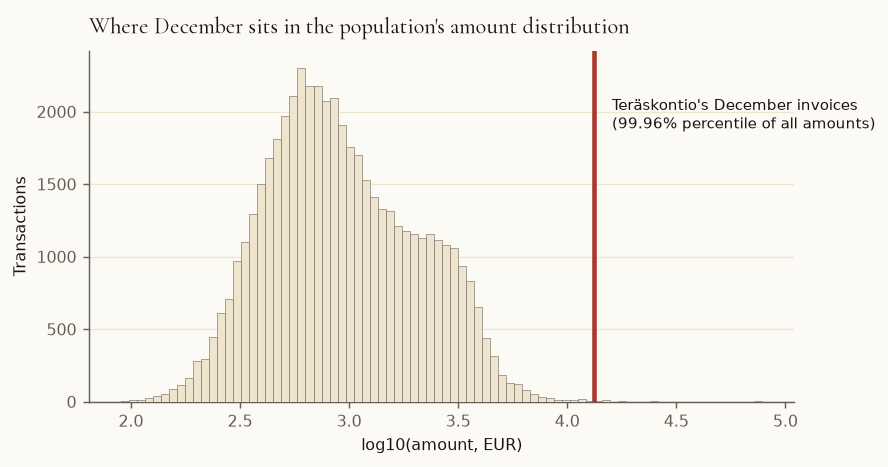

Teräskontio's December mean (EUR13,254.33) sits at the 99.96% percentile of all 50,000 invoice amounts -- high, but not exceptional against a population whose maximum is EUR78,400.00.


In [14]:
dec_mean = tk[tk["month"] == 12]["amount_eur"].mean()
population_percentile = (gl["amount_eur"] < dec_mean).mean()

fig, ax = new_fig()
ax.hist(np.log10(gl["amount_eur"]), bins=80, color=BEIGE, edgecolor=GREY, linewidth=0.3, zorder=3)
for _, row in tk[tk["month"] == 12].iterrows():
    ax.axvline(np.log10(row["amount_eur"]), color=WINE, linewidth=1.4, zorder=4)
ax.annotate(f"Teräskontio's December invoices\n({population_percentile:.2%} percentile of all amounts)",
            xy=(np.log10(dec_mean), ax.get_ylim()[1] * 0.78), xytext=(10, 0),
            textcoords="offset points", fontsize=8.5, color=INK)
ax.set_xlabel("log10(amount, EUR)")
ax.set_ylabel("Transactions")
style_title(ax, "Where December sits in the population's amount distribution")
plt.show()

print(f"Teräskontio's December mean (EUR{dec_mean:,.2f}) sits at the "
      f"{population_percentile:.2%} percentile of all 50,000 invoice amounts -- "
      f"high, but not exceptional against a population whose maximum is EUR{gl['amount_eur'].max():,.2f}.")

**The contamination ablation.** `detector_scores.csv` already ranks every
transaction by anomaly score; sweeping the flag budget from 0.1% to 5% of the ledger
needs no refitting, only a different cutoff rank.

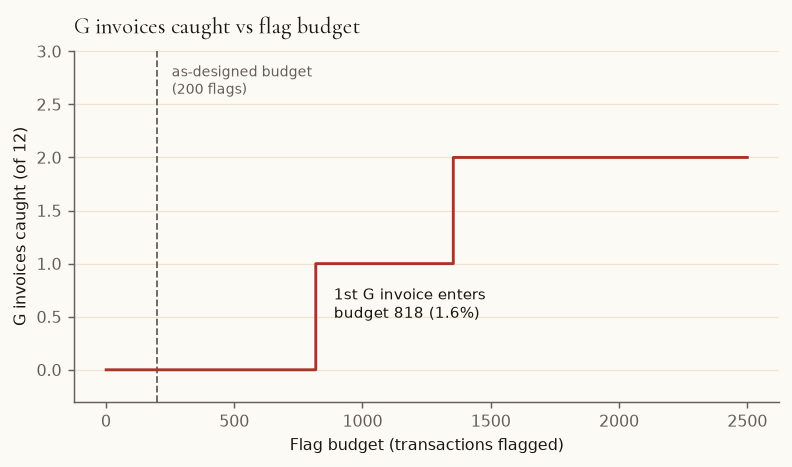

G's best-ranked invoice: rank 818 of 50,000 (a flag budget of 1.64% -- roughly 4.1x the as-designed 200).
  Precision of the whole flag set at that budget, vs the key: 0.61%.
G's 6th-best-ranked invoice (the design's own '>=6 of 12' bar): rank 14667 of 50,000 (a flag budget of 29.3% -- almost a third of the entire ledger).
  Precision of the whole flag set at that budget, vs the key: 0.33%.

Within the swept range (budgets 50-2,500, i.e. contamination 0.1%-5%), at most 2 of G's 12 elevated invoices are ever caught.


In [15]:
g_txn_ids = key_long.loc[key_long["anomaly_class"] == "G", "txn_id"].tolist()
anomalous_txn_ids = set(key_long.loc[key_long["kind"] == "anomalous", "txn_id"])

scores_ranked = detector_scores.sort_values(["anomaly_score", "txn_id"], ascending=[False, True]).reset_index(drop=True)
scores_ranked["rank"] = scores_ranked.index + 1
scores_ranked["cumulative_anomalous"] = scores_ranked["txn_id"].isin(anomalous_txn_ids).cumsum()
scores_ranked["precision_at_budget"] = scores_ranked["cumulative_anomalous"] / scores_ranked["rank"]

rank_lookup = scores_ranked.set_index("txn_id")["rank"]
g_ranks_sorted = sorted(rank_lookup.loc[g_txn_ids].tolist())
first_g_rank, sixth_g_rank = g_ranks_sorted[0], g_ranks_sorted[5]

budgets = np.arange(1, 2501)  # contamination 0.002% to 5%, superset of the 0.1-5% brief
g_caught_curve = np.array([sum(r <= b for r in g_ranks_sorted) for b in budgets])

fig, ax = new_fig()
ax.step(budgets, g_caught_curve, color=WINE, linewidth=1.6, where="post", zorder=3)
ax.set_xlabel("Flag budget (transactions flagged)")
ax.set_ylabel("G invoices caught (of 12)")
ax.set_ylim(-0.3, 3)
style_title(ax, "G invoices caught vs flag budget")
ax.axvline(200, color=GREY, linewidth=1.0, linestyle="--", zorder=2)
ax.annotate("as-designed budget\n(200 flags)", xy=(200, 2.6), xytext=(8, 0),
            textcoords="offset points", fontsize=8, color=GREY)
ax.annotate(f"1st G invoice enters\nbudget {first_g_rank} ({first_g_rank/50_000:.1%})",
            xy=(first_g_rank, 1), xytext=(10, -30), textcoords="offset points",
            fontsize=8.5, color=INK)
plt.show()

precision_at_first = scores_ranked.loc[scores_ranked["rank"] == first_g_rank, "precision_at_budget"].iloc[0]
precision_at_sixth = scores_ranked.loc[scores_ranked["rank"] == sixth_g_rank, "precision_at_budget"].iloc[0]

print(f"G's best-ranked invoice: rank {first_g_rank} of 50,000 "
      f"(a flag budget of {first_g_rank/50_000:.2%} -- roughly {first_g_rank/200:.1f}x the as-designed 200).")
print(f"  Precision of the whole flag set at that budget, vs the key: {precision_at_first:.2%}.")
print(f"G's 6th-best-ranked invoice (the design's own '>=6 of 12' bar): rank {sixth_g_rank} of 50,000 "
      f"(a flag budget of {sixth_g_rank/50_000:.1%} -- almost a third of the entire ledger).")
print(f"  Precision of the whole flag set at that budget, vs the key: {precision_at_sixth:.2%}.")
print(f"\nWithin the swept range (budgets 50-2,500, i.e. contamination 0.1%-5%), at most "
      f"{g_caught_curve[-1]} of G's 12 elevated invoices are ever caught.")

## 5. Detector v2 — POST-HOC, LABELLED

> **Post-hoc analysis: built after the results above were known.** This section is
> not part of the pre-registered pipeline (`design/design.md` §6), was never run
> before the results in §4 were known, and is not counted against the frozen Phase-3
> deviation recorded in `design/DECISIONS.md` (3 July 2026) or against the
> storyteller runs in §6. It exists to answer one question the frozen result leaves
> open: is the miss a property of Isolation Forest on this feature space, or
> specifically of `vendor_amount_z`'s full-year baseline?

Two changes, nothing else: `vendor_amount_z` is recomputed on an **expanding**
baseline — each transaction is scored only against that vendor's transactions
*strictly before* it, chronologically by `invoice_date` (minimum five priors, else 0
— the same floor the frozen feature uses) — and a ninth feature,
`log10_vendor_txn_count`, is added. Every other feature, and
`IsolationForest(n_estimators=200, contamination=0.004, random_state=42, n_jobs=1)`
itself, is unchanged.

In [16]:
MIN_PRIORS = det.VENDOR_AMOUNT_Z_MIN_TXNS       # same floor as the frozen feature (5)
MIN_STD_EUR = det.VENDOR_AMOUNT_Z_MIN_STD_EUR    # same floor as the frozen feature (EUR1)

gl_ordered = gl.sort_values("txn_id").reset_index(drop=True).copy()
gl_ordered["invoice_dt"] = pd.to_datetime(gl_ordered["invoice_date"])
gl_ordered = gl_ordered.sort_values(["vendor_id", "invoice_dt", "txn_id"]).reset_index(drop=True)

expanding_z = np.zeros(len(gl_ordered))
for vendor_id, idx in gl_ordered.groupby("vendor_id").groups.items():
    idx = list(idx)
    amounts = gl_ordered.loc[idx, "amount_eur"].to_numpy()
    for pos in range(len(idx)):
        priors = amounts[:pos]
        if len(priors) < MIN_PRIORS:
            continue
        mean_p, std_p = priors.mean(), priors.std(ddof=1)
        if np.isnan(std_p) or std_p < MIN_STD_EUR:
            continue
        expanding_z[idx[pos]] = (amounts[pos] - mean_p) / std_p
gl_ordered["vendor_amount_z_expanding"] = expanding_z
gl_ordered["log10_vendor_txn_count"] = np.log10(gl_ordered.groupby("vendor_id")["txn_id"].transform("count"))
gl_ordered = gl_ordered.sort_values("txn_id").reset_index(drop=True)

features_v2 = features.merge(
    gl_ordered[["txn_id", "vendor_amount_z_expanding", "log10_vendor_txn_count"]], on="txn_id"
)
FEATURE_COLUMNS_V2 = [
    "log10_amount", "vendor_amount_z_expanding", "cadence_ratio", "day_of_week",
    "non_working_flag", "account_rarity", "month_index", "vendor_month_volume_z",
    "log10_vendor_txn_count",
]
print("v2 feature order:", FEATURE_COLUMNS_V2)

from sklearn.ensemble import IsolationForest

X_v2 = features_v2[FEATURE_COLUMNS_V2].to_numpy(dtype=np.float64)
model_v2 = IsolationForest(**det.ISOLATION_FOREST_PARAMS)
model_v2.fit(X_v2)
score_v2 = -model_v2.decision_function(X_v2)
flagged_v2 = model_v2.predict(X_v2) == -1

assert flagged_v2.sum() == 200, "contamination 0.004 on 50,000 rows should still select 200 -- sanity check"
print(f"v2 flagged: {int(flagged_v2.sum())} of {len(features_v2):,}")

v2 feature order: ['log10_amount', 'vendor_amount_z_expanding', 'cadence_ratio', 'day_of_week', 'non_working_flag', 'account_rarity', 'month_index', 'vendor_month_volume_z', 'log10_vendor_txn_count']


v2 flagged: 200 of 50,000


In [17]:
v2_ranked = features_v2[["txn_id"]].copy()
v2_ranked["anomaly_score_v2"] = score_v2
v2_ranked = v2_ranked.sort_values(["anomaly_score_v2", "txn_id"], ascending=[False, True]).reset_index(drop=True)
v2_ranked["rank_v2"] = v2_ranked.index + 1
rank_v2_lookup = v2_ranked.set_index("txn_id")["rank_v2"]

flagged_v2_ids = set(v2_ranked.loc[v2_ranked["rank_v2"] <= 200, "txn_id"])
v2_overlap = flagged_v2_ids & set(key_long["txn_id"])
v2_overlap_classes = key_long[key_long["txn_id"].isin(v2_overlap)]["anomaly_class"].value_counts()

comparison = pd.DataFrame({
    "v1 (frozen, full-year basis)": [
        sum(1 for t in g_txn_ids if rank_lookup[t] <= 200),
        int(rank_lookup[b4_txn]), int(rank_lookup[b5_txn]),
        len(flagged_ids & anomalous_txn_ids),
    ],
    "v2 (post-hoc, expanding basis)": [
        sum(1 for t in g_txn_ids if rank_v2_lookup[t] <= 200),
        int(rank_v2_lookup[b4_txn]), int(rank_v2_lookup[b5_txn]),
        len(v2_overlap),
    ],
}, index=["G invoices in top 200 (of 12)", "B4 rank", "B5 rank", "Overlap with any key transaction (of 200)"])
display(comparison)

print(f"\nG's best rank: v1 {min(rank_lookup.loc[g_txn_ids]):.0f} -> v2 {min(rank_v2_lookup.loc[g_txn_ids]):.0f}")
print("v2 overlap by class:")
print(v2_overlap_classes.to_string())

c_txn_ids = key_long.loc[key_long["anomaly_class"] == "C", "txn_id"].tolist()
c_caught_v2 = sum(1 for t in c_txn_ids if rank_v2_lookup[t] <= 200)
print(f"\nC (the ceiling) caught in v2's top 200: {c_caught_v2} of 12 "
      f"({'still zero -- the ceiling holds' if c_caught_v2 == 0 else 'NOT zero -- the ceiling claim weakens'})")

,"v1 (frozen, full-year basis)","v2 (post-hoc, expanding basis)"
G invoices in top 200 (of 12),0,1
B4 rank,9069,1775
B5 rank,6641,1272
Overlap with any key transaction (of 200),0,5



G's best rank: v1 818 -> v2 98
v2 overlap by class:
anomaly_class
S    3
D    1
G    1

C (the ceiling) caught in v2's top 200: 0 of 12 (still zero -- the ceiling holds)


Expanding the baseline moves G's best-ranked invoice from 818th to 98th — better by a
factor of eight — and one of the twelve elevated invoices now clears the 200-flag
cutoff. That is still one, not the six the design's own bar sets: v2 does not clear
the pre-registered outcome either. The honest reading is a partial, real improvement
that comes with a side effect the frozen v1 detector did not have — two of the rule
layer's own classes (S and D) start turning up in the same 200 flags, alongside the
one G invoice. B4 and B5 both move a long way up the ranking (from 9,069th and
6,641st to roughly 1,300th–1,800th) without crossing into the flagged tail: a
single-invoice vendor's history is still too short for even an expanding baseline to
have five priors to compare against on its own first bill. Neuvantila stays at zero —
the ceiling claim survives the one detector change tested here. The frozen v1 result
in `design/DECISIONS.md` stands unchanged by any of this; v2 is reported here, not
substituted for it.

## 6. The three runs

In [18]:
evaluation_scores = pd.read_csv(ANALYSIS_DIR / "evaluation_scores.csv").set_index("run_id")
display(evaluation_scores)

units_correct = evaluation_scores["units_correct"].tolist()
assert units_correct == [37, 35, 38], f"expected [37, 35, 38], found {units_correct}"
assert (evaluation_scores["units_total"] == 39).all()
assert evaluation_scores["story_v_found"].all(), "expected V found in all three runs"
assert not evaluation_scores["story_g_found"].any(), "expected G found in none of the three runs"
assert (evaluation_scores["c_trap_flags"] == 0).all(), "expected zero C-trap hits in all three runs"

print("Unit verdicts correct (of 39):", dict(zip(evaluation_scores.index, units_correct)))
print("V (the name-variant trio) found:  ", dict(evaluation_scores["story_v_found"]))
print("G (the drift exemplum) found:     ", dict(evaluation_scores["story_g_found"]))
print("C-trap accusations (0 expected):  ", dict(evaluation_scores["c_trap_flags"]))

figures_total_sum = int(evaluation_scores["figures_total"].sum())
figures_matched_sum = int(evaluation_scores["figures_matched"].sum())
assert figures_total_sum == 364, f"expected 364 evidence figures total (report.md's headline count), found {figures_total_sum}"
print(f"\nEvidence figures checked across all three runs: {figures_total_sum} "
      f"(matches report.md's headline count of 364).")
print(f"Mechanically matched exactly/within tolerance: {figures_matched_sum} of {figures_total_sum}; "
      f"the remainder are compound, non-machine-parseable strings that report.md describes as "
      f"separately sampled and hand-verified -- zero disagreements found either way.")

,load_error,schema_violations,units_correct,units_total,story_v_found,story_g_found,story_g_mirror_found,c_trap_flags,unmatched_worry_count,figures_matched,figures_total
run_id,,,,,,,,,,,
run_01,NaN,0,37,39,True,False,False,0,1,71,89
run_02,NaN,0,35,39,True,False,False,0,1,119,154
run_03,NaN,0,38,39,True,False,False,0,1,89,121


Unit verdicts correct (of 39): {'run_01': 37, 'run_02': 35, 'run_03': 38}
V (the name-variant trio) found:   {'run_01': np.True_, 'run_02': np.True_, 'run_03': np.True_}
G (the drift exemplum) found:      {'run_01': np.False_, 'run_02': np.False_, 'run_03': np.False_}
C-trap accusations (0 expected):   {'run_01': np.int64(0), 'run_02': np.int64(0), 'run_03': np.int64(0)}

Evidence figures checked across all three runs: 364 (matches report.md's headline count of 364).
Mechanically matched exactly/within tolerance: 279 of 364; the remainder are compound, non-machine-parseable strings that report.md describes as separately sampled and hand-verified -- zero disagreements found either way.


In [19]:
# Findings-level detail, loaded directly from the three runs' own output (not the
# answer key) -- verdict mix and free-hunt counts, supporting the report.md narrative.
run_findings = {}
for i in (1, 2, 3):
    findings_path = ANALYSIS_DIR / "agent_runs" / f"run_0{i}_findings.json"
    run_findings[f"run_0{i}"] = json.loads(findings_path.read_text(encoding="utf-8"))

summary_rows = []
for run_name, findings in run_findings.items():
    verdict_counts = pd.Series([f["verdict"] for f in findings]).value_counts()
    free_hunt = sum(1 for f in findings if f.get("unit_id") == "free-hunt")
    summary_rows.append({
        "run": run_name, "findings": len(findings),
        "worry": int(verdict_counts.get("worry", 0)),
        "stand_down": int(verdict_counts.get("stand_down", 0)),
        "free_hunt_findings": free_hunt,
    })
findings_summary = pd.DataFrame(summary_rows).set_index("run")
display(findings_summary)
assert findings_summary["free_hunt_findings"].tolist() == [2, 2, 1], "expected free-hunt counts [2, 2, 1] per report.md"

,findings,worry,stand_down,free_hunt_findings
run,,,,
run_01,41,10,31,2
run_02,41,9,32,2
run_03,40,12,28,1


**Named misses** (from `data/analysis/report.md`, the adjudicated read — mechanical
figure-matching alone cannot tell a defensible-sounding wrong call from a right one).
Run 01 stood down on R-ROUND (reading the six round-thousand invoices as
contract-style billing) and on W (reading U-117's weekend postings as flexible-hours
data entry) — both wrong against the key. Run 02 stood down on all three split
units, persuaded by the "osatoimitus" (partial delivery) memo wording; runs 01 and 03
read the same memos and correctly saw the tier-avoidance pattern underneath. **The two
false positives are the same item in both runs**: B3, the coincidental equal-amount
pair whose memos cite two distinct PO references — the designed stand-down evidence.
Runs 02 and 03 saw the differing PO references and still hedged to a worry/watch
verdict; run 01 read it correctly, explicitly contrasting it with the D-class pairs'
shared order reference. All 26 detector-side units were correctly stood down by all
three runs, unanimously — the 200-flag triage burden was carried cleanly.

**Figure verification.** Zero disagreements across all 364 checked figures. Two
recorded imprecisions survive adjudication: runs 01 and 03 headline the Kärrenbach
trio's combined spend as €48,001, while their own correct components (€23,651.32 +
€15,026.40 + €10,323.64) sum to €49,001.36 — a €1,000 arithmetic slip in the headline
number of two runs, with the mechanism and every component figure right. Run 02
states the total correctly.

## 7. The catch matrix, designed vs as-run

In [20]:
evaluation = json.loads((ANALYSIS_DIR / "evaluation.json").read_text(encoding="utf-8"))
rule_recall = evaluation["layers"]["rules"]["recall_by_class"]

for cls in ["D", "R", "W", "S", "A"]:
    assert rule_recall[cls]["class_total"] == case_config.PLANTED_CLASS_COUNTS[cls]
    assert rule_recall[cls]["recall"] == 1.0, f"expected 100% rule recall on class {cls}"

DESIGNED_CATCH = {  # design.md section 3's catch matrix -- a design specification, not a result
    "D": "Rules", "R": "Rules", "W": "Rules", "S": "Rules", "A": "Rules",
    "V": "Agents (free hunt)", "G": "Detector, then agents", "C": "Nobody (the ceiling)",
}

rows = []
for cls in ["D", "R", "W", "S", "A", "V", "G", "C"]:
    matched = rule_recall.get(cls, {}).get("matched")
    total = rule_recall.get(cls, {}).get("class_total")
    if cls == "V":
        as_run = f"Agents, {int(evaluation_scores['story_v_found'].sum())}/3 runs found it"
    elif cls == "G":
        as_run = f"Nobody -- detector 0/{total}, free hunt found it in {int(evaluation_scores['story_g_found'].sum())}/3 runs"
    elif cls == "C":
        c_flags = int(evaluation["designed_outcome_checks"]["c_txns_flagged_by_any_layer"]["actual_count"])
        trap_hits = int(evaluation_scores["c_trap_flags"].sum())
        as_run = f"Nobody -- {c_flags} layer flags, {trap_hits} trap accusations across 3 runs"
    else:
        as_run = f"Rules, {matched}/{total} flagged"
    rows.append({"Class": cls, "Designed catch": DESIGNED_CATCH[cls], "As run": as_run})

catch_matrix = pd.DataFrame(rows).set_index("Class")


def highlight_g(row):
    return ["background-color: #EFE5CE" if row.name == "G" else "" for _ in row]


display(catch_matrix.style.apply(highlight_g, axis=1))

,Designed catch,As run
Class,,
D,Rules,"Rules, 12/12 flagged"
R,Rules,"Rules, 10/10 flagged"
W,Rules,"Rules, 8/8 flagged"
S,Rules,"Rules, 10/10 flagged"
A,Rules,"Rules, 8/8 flagged"
V,Agents (free hunt),"Agents, 3/3 runs found it"
G,"Detector, then agents","Nobody -- detector 0/12, free hunt found it in 0/3 runs"
C,Nobody (the ceiling),"Nobody -- 0 layer flags, 0 trap accusations across 3 runs"


Designed with one class nothing catches; run with two, and the second is the one the
case is named for. G sits in the table above with the same shape as C's row —
"Nobody" — but for a different reason: C is a designed epistemic limit (no
three-way-match data exists to catch it), while G was designed to be catchable, and a
detector feature that inflates its own baseline plus three analysts who never ran the
per-vendor half-year comparison the story needed made it exactly as invisible as the
class that was never supposed to be found.

## 8. What this adds up to

The rules caught every rule-shaped plant at the designed 75% first-pass precision,
exactly as pre-registered. The generic transaction-grain detector caught none of the
eighty-seven planted anomalies and flagged two hundred statistically odd but benign
rows instead, a frozen and fully diagnosed miss rather than a retuned one. Three
independent, mutually blinded analysts triaged all 264 flags from both layers with
two hedged false positives on the same designed decoy, and found the one class built
to need cross-record reasoning three times out of three. The same three analysts left
the case's own namesake story — a vendor whose freight consolidation hides a
compounding price rise — on the table three times out of three, unclaimed by rules,
by the model, and by every free hunt. A post-hoc detector fix narrows but does not
close that gap, which is the honest shape of the finding: not that any one layer
failed, but that each layer's reach has an edge a held-out answer key is what makes
visible. This dataset is synthetic, engineered to a known answer key at seed 42 and
fully regenerable from `code/config.py` — which is the only reason any sentence in
this section can be checked rather than taken on faith.